<p align="center">
  <img src="https://www.portafolio.co/files/article_new_multimedia/uploads/2023/10/12/652828e536642.jpeg" style="width:100%; max-width:900px; height:180px; object-fit:cover; border-radius:10px;"/>
</p>
<div style="text-align:center;">
  <h1 style="color:#FFD700; display:inline-block; margin:0;">Optimización del Transporte en Nueva York</h1>
  <p>
    <b>Green Taxi | Machine Learning & Data Science | CRISP-DM</b><br>
    <span style="font-size:1.1em;">Análisis y predicción de tarifas y duración de viajes usando datos reales de taxis verdes de NYC.</span>
  </p>
</div>

In [1]:
# Verifica si las librerías necesarias ya están instaladas
try:
    # Ignorar warnings
    import warnings
    warnings.filterwarnings('ignore')
    # Librerías del sistema
    import sys, subprocess
    # Importaciones base
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import os
    import joblib
    import scipy.stats as stats
    import pickle as pkl
    from sklearn.impute import KNNImputer
    import category_encoders as ce

    # Establece el tema global
    sns.set_theme(
    style="whitegrid",                  # El estilo del gráfico (fondo y cuadrícula)
        palette="colorblind",           # La paleta de colores
        font="sans-serif",               # La familia de la fuente
        font_scale=0.9,                  # Escala de la fuente
        rc={"axes.titlesize": 14, "axes.labelsize": 12, "xtick.labelsize": 10, "ytick.labelsize": 10}
    )
    
    print("Dependencias ya instaladas.")

except ImportError:

    print("Dependencias no encontradas. Instalando ahora...")
    
    # Se ejecutan los comandos de instalación
    %pip install --quiet matplotlib
    %pip install --quiet seaborn
    %pip install --quiet joblib
    %pip install --quiet scipy
    %pip install --quiet category_encoders
    
    print("Instalación completada.")

Dependencias ya instaladas.


In [2]:
# Función lambda para verificar e instalar
instalar = lambda p: subprocess.call([sys.executable, "-c", f"import {p}"]) and subprocess.call([sys.executable, "-m", "pip", "install", p, "-q"])

# Actualizar pip
subprocess.call([sys.executable, "-m", "pip", "install", "--upgrade", "pip", "-q"])

# Verificar e instalar condicionalmente
if instalar("pyarrow") == 0: print("PyArrow instalado/verificado")
if instalar("fastparquet") == 0: print("FastParquet instalado/verificado")

print("Listo para usar")

PyArrow instalado/verificado
FastParquet instalado/verificado
Listo para usar


# 03.- Data Preparation

In [3]:
# Configuración del dataset desde el directorio local
parquet_file = "cleaned_green_tripdata_2025-06.parquet"
df_prep = pd.read_parquet(parquet_file, engine="pyarrow")

In [4]:
#  Drop pickup_year
try:
    df_prep = df_prep.drop(columns=['pickup_year'])
    print("Columna 'pickup_year' eliminada.")
except KeyError:
    print("Columna 'pickup_year' no existe, continuando...")

Columna 'pickup_year' eliminada.


In [5]:
#  Drop pickup_month
try:
    df_prep = df_prep.drop(columns=['pickup_month'])
    print("Columna 'pickup_month' eliminada.")
except KeyError:
    print("Columna 'pickup_month' no existe, continuando...")

Columna 'pickup_month' eliminada.


In [6]:
# Drop ehail_fee
try:
    df_prep = df_prep.drop(columns=['ehail_fee'])
    print("Columna 'ehail_fee' eliminada.")
except KeyError:
    print("Columna 'ehail_fee' no existe, continuando...")

Columna 'ehail_fee' no existe, continuando...


In [7]:
# Check if binary encoding is already applied
if 'store_and_fwd_flag_0' in df_prep.columns and 'store_and_fwd_flag_1' in df_prep.columns:
	print("Binary encoding for 'store_and_fwd_flag' already exists")
	df_prep_bin = df_prep[['store_and_fwd_flag_0', 'store_and_fwd_flag_1']].copy()
else:
	# Create binary encoder for categorical columns
	encoder = ce.BinaryEncoder(cols=['store_and_fwd_flag'])
	df_prep_bin = encoder.fit_transform(df_prep[['store_and_fwd_flag']])
	df_prep = pd.concat([df_prep, df_prep_bin], axis=1)


In [8]:
# Check if binary encoding is already applied
if 'trip_type' in df_prep.columns and 'trip_type_1' in df_prep.columns:
	print("Binary encoding for 'trip_type' already exists")
	df_prep_bin = df_prep[['trip_type_0', 'trip_type_1']].copy()
else:
	# Create binary encoder for categorical columns
	encoder = ce.BinaryEncoder(cols=['trip_type'])
	df_prep_bin = encoder.fit_transform(df_prep[['trip_type']])
	df_prep = pd.concat([df_prep, df_prep_bin], axis=1)

In [9]:
# Drop store_and_fwd_flag
try:
    df_prep = df_prep.drop(columns=['trip_type'])
    print("Columna 'trip_type' eliminada.")
except KeyError:
    print("Columna 'trip_type' no existe, continuando...")

Columna 'trip_type' eliminada.


In [10]:
# Drop store_and_fwd_flag
try:
    df_prep = df_prep.drop(columns=['store_and_fwd_flag'])
    print("Columna 'store_and_fwd_flag' eliminada.")
except KeyError:
    print("Columna 'store_and_fwd_flag' no existe, continuando...")

Columna 'store_and_fwd_flag' eliminada.


### Acotación Método del IQR (Interquartile Range)

In [11]:
# Análisis y Tratamiento de Outliers con el Método IQR
df_iqr = df_prep.copy()

# Identificar columnas numéricas float64
columnas_a_tratar = df_prep.select_dtypes(include=['float64']).columns
print("\nDetección y Corrección de Outliers (Método IQR)")

# --- Encabezado de la tabla ---
print(f"{'Columna':<25} | {'Outliers':>10} | {'Límites (inf, sup)':>30} | {'Porcentaje':>12}")
print("-" * 90) # Ajusta el número de guiones si es necesario

# Iterar sobre las columnas para detectar y corregir outliers
for columna in columnas_a_tratar:
    if pd.api.types.is_numeric_dtype(df_iqr[columna]):
        # Calcular Q1, Q3 e IQR
        Q1 = df_iqr[columna].quantile(0.25)
        Q3 = df_iqr[columna].quantile(0.75)
        IQR = Q3 - Q1

        # Definir límites para outliers
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        # Detectar outliers
        outliers_indices = (df_iqr[columna] < limite_inferior) | (df_iqr[columna] > limite_superior)
        outliers_count = outliers_indices.sum() 
        
        if outliers_count > 0:
            total_rows = len(df_iqr)
            percentage = (outliers_count / total_rows) * 100
            
            # --- Impresión formateada como fila de tabla ---
            print(f"{columna:<25} |{limite_inferior:>12.2f} | {limite_superior:>12.2f}) |  {outliers_count:>10} | {percentage:>10.2f}%")
            
            # Corregir outliers usando clip
            df_iqr[columna] = df_iqr[columna].clip(lower=limite_inferior, upper=limite_superior)
        else: 
            # --- Impresión formateada para columnas sin outliers ---
            print(f"{columna:<25} | {'No outliers':>10} | {'-':>12} | {'-':>30}")

# --- Dimensiones finales ---
print("\n--- Dimensiones del dataset después de la corrección ---")
print(f"Total de columnas: {df_iqr.shape[1]}")
print(f"Total de filas: {df_iqr.shape[0]}")


Detección y Corrección de Outliers (Método IQR)
Columna                   |   Outliers |             Límites (inf, sup) |   Porcentaje
------------------------------------------------------------------------------------------
trip_distance             |       -2.19 |         7.01) |        4710 |       9.54%
fare_amount               |       -6.80 |        38.00) |        4098 |       8.30%
extra                     |       -1.50 |         2.50) |        3060 |       6.20%
mta_tax                   |        0.50 |         0.50) |        8058 |      16.32%
tolls_amount              |        0.00 |         0.00) |        1848 |       3.74%
improvement_surcharge     |        1.00 |         1.00) |        2160 |       4.37%
congestion_surcharge      | No outliers |            - |                              -
cbd_congestion_fee        |        0.00 |         0.00) |        4913 |       9.95%
tip_amount                |       -6.00 |        10.00) |        1593 |       3.23%
total_amount 

### Acotación por Percentiles (Winsorizing) 3% y 97%


In [12]:
# Análisis y Tratamiento de Outliers con percentiles 3% Y 97%
df_winsorized = df_prep.copy()
# Identificar columnas numéricas float64
columnas_a_tratar = df_winsorized.select_dtypes(include=['float64']).columns 

print("\nCorrección de Outliers (Acotación por Percentiles 3% y 97%)")
print(f"{'Columna':<25} | {'Límite Inferior (P3)':>20} | {'Límite Superior (P97) |':>20}")
print("-" * 100)

for columna in columnas_a_tratar:
    if pd.api.types.is_numeric_dtype(df_winsorized[columna]):

        # --- Calcular límites usando percentiles 3 y 97 ---
        limite_inferior = df_winsorized[columna].quantile(0.03)
        limite_superior = df_winsorized[columna].quantile(0.97)
        
        # Contar cuántos valores serán acotados (opcional, para información)
        outliers_bajos = df_winsorized[df_winsorized[columna] < limite_inferior].shape[0]
        outliers_altos = df_winsorized[df_winsorized[columna] > limite_superior].shape[0]
        total_outliers = outliers_bajos + outliers_altos
        percentage = (total_outliers / len(df_winsorized)) * 100

        print(f"{columna:<25} | {limite_inferior:>20.2f} | {limite_superior:>20.2f} | {total_outliers} acotados ({percentage:.2f}%)")
        
        # --- Aplicar la acotación ---
        df_winsorized[columna] = df_winsorized[columna].clip(lower=limite_inferior, upper=limite_superior)

print("\nDimensiones del dataset después de la corrección")
print(f"Total de columnas: {df_winsorized.shape[1]}")
print(f"Total de filas: {df_winsorized.shape[0]}")
'''
Acotación por Percentiles (Winsorizing) 

Esta es una alternativa muy directa y controlable. En lugar de usar los límites calculados por el IQR, defines los límites directamente como percentiles de tus datos.

Concepto: Reemplazas los valores extremos con los valores de los percentiles más cercanos. Por ejemplo, reemplazas todos 
los valores por debajo del percentil 5 con el valor del percentil 5, y todos los valores por encima del percentil 95 con el valor del percentil 95. 
Los percentiles comunes a usar son (1% y 99%) o (5% y 95%).

Ventajas: Tienes control directo sobre qué porcentaje de tus datos se ve afectado. Es robusto a la forma de la distribución.

Implementación: Es muy fácil con .quantile() y .clip().
'''



Corrección de Outliers (Acotación por Percentiles 3% y 97%)
Columna                   | Límite Inferior (P3) | Límite Superior (P97) |
----------------------------------------------------------------------------------------------------
trip_distance             |                 0.00 |                12.19 | 1481 acotados (3.00%)
fare_amount               |                 2.90 |                62.50 | 1861 acotados (3.77%)
extra                     |                 0.00 |                 5.00 | 892 acotados (1.81%)
mta_tax                   |                 0.00 |                 1.50 | 141 acotados (0.29%)
tolls_amount              |                 0.00 |                 6.94 | 93 acotados (0.19%)
improvement_surcharge     |                 0.30 |                 1.00 | 513 acotados (1.04%)
congestion_surcharge      |                 0.00 |                 2.75 | 5 acotados (0.01%)
cbd_congestion_fee        |                 0.00 |                 0.75 | 2 acotados (0.00%)
tip_am

'\nAcotación por Percentiles (Winsorizing) \n\nEsta es una alternativa muy directa y controlable. En lugar de usar los límites calculados por el IQR, defines los límites directamente como percentiles de tus datos.\n\nConcepto: Reemplazas los valores extremos con los valores de los percentiles más cercanos. Por ejemplo, reemplazas todos \nlos valores por debajo del percentil 5 con el valor del percentil 5, y todos los valores por encima del percentil 95 con el valor del percentil 95. \nLos percentiles comunes a usar son (1% y 99%) o (5% y 95%).\n\nVentajas: Tienes control directo sobre qué porcentaje de tus datos se ve afectado. Es robusto a la forma de la distribución.\n\nImplementación: Es muy fácil con .quantile() y .clip().\n'

# Comparación de estadísticas antes y después de la acotación

In [13]:
# 4. Verificar los resultados
# --- Estadísticas del DataFrame ORIGINAL ---
print("Estadísticas del DataFrame ORIGINAL")
stats_original = df_prep[columnas_a_tratar].describe().round(2).T
stats_original

Estadísticas del DataFrame ORIGINAL


,count,mean,std,min,25%,50%,75%,max
trip_distance,49390.0,10.12,618.78,0.00,1.26,2.03,3.56,77463.55
fare_amount,49390.0,18.80,18.13,-200.00,10.00,14.20,21.20,588.20
extra,49390.0,0.88,1.38,-5.00,0.00,0.00,1.00,7.50
mta_tax,49390.0,0.57,0.34,-0.50,0.50,0.50,0.50,1.50
tolls_amount,49390.0,0.27,1.48,0.00,0.00,0.00,0.00,49.94
improvement_surcharge,49390.0,0.96,0.19,-1.00,1.00,1.00,1.00,1.00
congestion_surcharge,45605.0,0.90,1.29,-2.75,0.00,0.00,2.75,2.75
cbd_congestion_fee,49390.0,0.07,0.22,-0.75,0.00,0.00,0.00,0.75
tip_amount,49390.0,2.77,3.76,-0.90,0.00,2.16,4.00,153.30
total_amount,49390.0,25.80,20.64,-201.00,14.70,20.35,29.70,589.70


In [14]:
# --- Estadísticas del DataFrame IQR ---
print("Estadísticas del DataFrame IQR")
stats_iqr = df_iqr[columnas_a_tratar].describe().round(2).T
stats_iqr

Estadísticas del DataFrame IQR


,count,mean,std,min,25%,50%,75%,max
trip_distance,49390.0,2.68,2.02,0.00,1.26,2.03,3.56,7.01
fare_amount,49390.0,16.71,9.76,-6.80,10.00,14.20,21.20,38.00
extra,49390.0,0.76,1.04,-1.50,0.00,0.00,1.00,2.50
mta_tax,49390.0,0.50,0.00,0.50,0.50,0.50,0.50,0.50
tolls_amount,49390.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
improvement_surcharge,49390.0,1.00,0.00,1.00,1.00,1.00,1.00,1.00
congestion_surcharge,45605.0,0.90,1.29,-2.75,0.00,0.00,2.75,2.75
cbd_congestion_fee,49390.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
tip_amount,49390.0,2.58,2.69,-0.90,0.00,2.16,4.00,10.00
total_amount,49390.0,23.76,12.55,-7.80,14.70,20.35,29.70,52.20


In [15]:
# --- Estadísticas del DataFrame Winsorized ---
print("Estadísticas del DataFrame Winsorized")
stats_winsorized = df_winsorized[columnas_a_tratar].describe().round(2).T
stats_winsorized

Estadísticas del DataFrame Winsorized


,count,mean,std,min,25%,50%,75%,max
trip_distance,49390.0,2.96,2.77,0.0,1.26,2.03,3.56,12.19
fare_amount,49390.0,17.97,13.03,2.9,10.00,14.20,21.20,62.50
extra,49390.0,0.86,1.29,0.0,0.00,0.00,1.00,5.00
mta_tax,49390.0,0.57,0.33,0.0,0.50,0.50,0.50,1.50
tolls_amount,49390.0,0.25,1.30,0.0,0.00,0.00,0.00,6.94
improvement_surcharge,49390.0,0.97,0.14,0.3,1.00,1.00,1.00,1.00
congestion_surcharge,45605.0,0.90,1.29,0.0,0.00,0.00,2.75,2.75
cbd_congestion_fee,49390.0,0.07,0.22,0.0,0.00,0.00,0.00,0.75
tip_amount,49390.0,2.58,2.71,0.0,0.00,2.16,4.00,10.27
total_amount,49390.0,24.91,15.23,8.0,14.70,20.35,29.70,74.46


In [16]:
df_prep = df_winsorized.copy()
print("Limpieza de outliers completada. DataFrame actualizado.")

Limpieza de outliers completada. DataFrame actualizado.


In [17]:
# Procesamiento de valores faltantes
# Seleccionar columnas numéricas
df_missing = df_winsorized.select_dtypes(include=[np.number]).columns.tolist()

# Validar que las columnas existan y sean numéricas
df_missing = [col for col in df_missing if col in df_winsorized.columns and pd.api.types.is_numeric_dtype(df_winsorized[col])]

# Crear copia de trabajo
df_missing = df_winsorized[df_missing].copy()

print("\nAnálisis de Valores Faltantes")
print(f"Columnas numéricas seleccionadas: {len(df_missing.columns)}")

# --- Encabezado de la tabla de imputación ---
print("\nImputación de Valores Faltantes (NaN) con Mediana")
print(f"{'Columna':<30} | {'NaNs Rellenados':>15} | {'Mediana Usada':>15}")
print("-" * (30 + 3 + 15 + 3 + 15 + 2)) # Ajusta el número de guiones

# --- Iterar e Imprimir en formato tabla ---
imputed_cols_count = 0
for col in df_missing.columns:
    if pd.api.types.is_numeric_dtype(df_missing[col]): # Check if numeric
        missing_before = df_missing[col].isnull().sum()
        if missing_before > 0:
            median_val = df_missing[col].median()
            df_missing[col] = df_missing[col].fillna(median_val)
            # Imprimir fila de tabla para columna imputada
            print(f"{col:<30} | {missing_before:>15} | {median_val:>15.2f}")
            imputed_cols_count += 1
        else:
            # Imprimir fila de tabla para columna sin NaNs
            print(f"{col:<30} | {'0':>15} | {'-':>15}")
    else:
         # Imprimir fila para columnas no numéricas (opcional)
         print(f"{col:<30} | {'No numérico':>15} | {'-':>15}")

if imputed_cols_count == 0:
    print("\n(No se encontraron valores NaN para imputar en las columnas numéricas)")


Análisis de Valores Faltantes
Columnas numéricas seleccionadas: 25

Imputación de Valores Faltantes (NaN) con Mediana
Columna                        | NaNs Rellenados |   Mediana Usada
--------------------------------------------------------------------
VendorID                       |               0 |               -
pickup_day                     |               0 |               -
pickup_hour                    |               0 |               -
pickup_minute                  |               0 |               -
pickup_second                  |               0 |               -
trip_duration_min              |               0 |               -
PULocationID                   |               0 |               -
DOLocationID                   |               0 |               -
trip_distance                  |               0 |               -
passenger_count                |            3785 |            1.00
RatecodeID                     |            3785 |            1.00
fare_amo

In [18]:
# Assuming df_winsorized is your DataFrame
df_winsorized_del = df_winsorized.copy()

# Define potential columns with nulls
columnas_con_nulos_potenciales = ['passenger_count', 'trip_type', 'store_and_fwd_flag', 
                                    'RatecodeID', 'congestion_surcharge', 'payment_type']

# Filter only existing columns
columnas_con_nulos = [col for col in columnas_con_nulos_potenciales if col in df_winsorized_del.columns]

# --- Formatted Print Start ---
print("\nTratamiento de Valores Nulos: Eliminación de Filas (Listwise Deletion)")

print(f"Columnas verificadas para nulos:")
for col in columnas_con_nulos:
    print(f"- {col}") # List format

# Get row counts
rows_before = len(df_winsorized_del)

# Perform deletion
if columnas_con_nulos:
    df_winsorized_del.dropna(subset=columnas_con_nulos, inplace=True)
    rows_after = len(df_winsorized_del)
    rows_deleted = rows_before - rows_after
    percentage_deleted = (rows_deleted / rows_before * 100) if rows_before > 0 else 0

    # --- Summary Table Print ---
    print("\nResumen de Eliminación")
    print(f"{'Métrica':<30} | {'Valor':>15}")
    print("-" * (30 + 3 + 15 + 2))
    print(f"{'Filas Originales':<30} | {rows_before:>15,}") # Add comma separators
    print(f"{'Filas Eliminadas':<30} | {rows_deleted:>15,}")
    print(f"{'Filas Restantes':<30} | {rows_after:>15,}")
    print(f"{'Porcentaje Eliminado':<30} | {percentage_deleted:>14.2f}%")
    print("-" * (30 + 3 + 15 + 2))

else:
    print("\nNo se especificaron columnas válidas para verificar nulos.")
    print("No se eliminaron filas.")
    rows_after = rows_before # Ensure rows_after is defined

print(f"\nDimensiones finales del DataFrame: ({rows_after}, {df_winsorized_del.shape[1]})")
print("---") # Markdown separator


Tratamiento de Valores Nulos: Eliminación de Filas (Listwise Deletion)
Columnas verificadas para nulos:
- passenger_count
- RatecodeID
- congestion_surcharge
- payment_type

Resumen de Eliminación
Métrica                        |           Valor
--------------------------------------------------
Filas Originales               |          49,390
Filas Eliminadas               |           3,785
Filas Restantes                |          45,605
Porcentaje Eliminado           |           7.66%
--------------------------------------------------

Dimensiones finales del DataFrame: (45605, 27)
---


In [19]:
# Procesamiento de valores faltantes
# Seleccionar columnas numéricas
df_del = df_winsorized_del.select_dtypes(include=[np.number]).columns.tolist()

# Validar que las columnas existan y sean numéricas
df_del = [col for col in df_del if col in df_winsorized_del.columns and pd.api.types.is_numeric_dtype(df_winsorized_del[col])]

# Crear copia de trabajo
df_missing = df_winsorized_del[df_del].copy()

print("\nAnálisis de Valores Faltantes")
print(f"Columnas numéricas seleccionadas: {len(df_missing.columns)}")

# --- Encabezado de la tabla de imputación ---
print("\nImputación de Valores Faltantes (NaN) con Mediana")
print(f"{'Columna':<30} | {'NaNs Rellenados':>15} | {'Mediana Usada':>15}")
print("-" * (30 + 3 + 15 + 3 + 15 + 2)) # Ajusta el número de guiones

# --- Iterar e Imprimir en formato tabla ---
imputed_cols_count = 0
for col in df_missing.columns:
    if pd.api.types.is_numeric_dtype(df_missing[col]): # Check if numeric
        missing_before = df_missing[col].isnull().sum()
        if missing_before > 0:
            median_val = df_missing[col].median()
            df_missing[col] = df_missing[col].fillna(median_val)
            # Imprimir fila de tabla para columna imputada
            print(f"{col:<30} | {missing_before:>15} | {median_val:>15.2f}")
            imputed_cols_count += 1
        else:
            # Imprimir fila de tabla para columna sin NaNs
            print(f"{col:<30} | {'0':>15} | {'-':>15}")
    else:
         # Imprimir fila para columnas no numéricas (opcional)
         print(f"{col:<30} | {'No numérico':>15} | {'-':>15}")

if imputed_cols_count == 0:
    print("\n(No se encontraron valores NaN para imputar en las columnas numéricas)")


Análisis de Valores Faltantes
Columnas numéricas seleccionadas: 25

Imputación de Valores Faltantes (NaN) con Mediana
Columna                        | NaNs Rellenados |   Mediana Usada
--------------------------------------------------------------------
VendorID                       |               0 |               -
pickup_day                     |               0 |               -
pickup_hour                    |               0 |               -
pickup_minute                  |               0 |               -
pickup_second                  |               0 |               -
trip_duration_min              |               0 |               -
PULocationID                   |               0 |               -
DOLocationID                   |               0 |               -
trip_distance                  |               0 |               -
passenger_count                |               0 |               -
RatecodeID                     |               0 |               -
fare_amo

In [20]:
# Crear una copia para no modificar df_prep_clean original
df_prep_knn = df_winsorized.copy()

# --- Definir columnas existentes ---
# Filtrar solo las columnas que existen en el DataFrame
col_categoricas_nulos = ['trip_type', 'store_and_fwd_flag', 'RatecodeID', 'payment_type']
col_categoricas_existentes = [col for col in col_categoricas_nulos if col in df_prep_knn.columns]

# Definir columnas numéricas existentes
cols_numericas_existentes = df_prep_knn.select_dtypes(include=[np.number]).columns.tolist()

# Lista para guardar los resultados de la imputación
imputation_summary = []

# --- Inicio del Formato Tabular ---
print("\nTratamiento de Valores Nulos: Imputación KNN y Moda")

# --- Paso A: Imputar columnas categóricas con nulos (usando la moda) ---
print("Imputando columnas categóricas...")
for col in col_categoricas_existentes:
    if df_prep_knn[col].isnull().any():
        mode_val = df_prep_knn[col].mode()[0]
        missing_count = df_prep_knn[col].isnull().sum()
        df_prep_knn[col].fillna(mode_val, inplace=True)
        imputation_summary.append({'Columna': col, 'Método': 'Moda', 'NaNs Rellenados': missing_count, 'Valor Usado': mode_val})
    else:
        imputation_summary.append({'Columna': col, 'Método': 'Moda', 'NaNs Rellenados': 0, 'Valor Usado': '-'})


# --- Paso B: Imputar columnas numéricas con nulos usando KNN ---
print("Imputando columnas numéricas...")
cols_a_imputar_knn = [col for col in cols_numericas_existentes if df_prep_knn[col].isnull().any()]

if cols_a_imputar_knn:
    imputer = KNNImputer(n_neighbors=5)
    # Guardar los conteos de NaNs antes de imputar
    missing_counts_knn = {col: df_prep_knn[col].isnull().sum() for col in cols_a_imputar_knn}

    # Aplicar KNN
    df_prep_knn[cols_a_imputar_knn] = imputer.fit_transform(df_prep_knn[cols_a_imputar_knn])

    # Convertir tipos si es necesario y añadir al resumen
    for col in cols_a_imputar_knn:
        if 'passenger_count' == col:
             # Usamos Int64 para permitir posibles NaNs residuales (aunque no debería haber)
            df_prep_knn[col] = df_prep_knn[col].round().astype('Int64')
        imputation_summary.append({'Columna': col, 'Método': 'KNN (k=5)', 'NaNs Rellenados': missing_counts_knn[col], 'Valor Usado': '(Estimado)'})
else:
    print("No se encontraron columnas numéricas con nulos para imputar con KNN.")
    # Añadir info al resumen si las columnas existen pero no tienen nulos
    for col in cols_numericas_existentes:
        imputation_summary.append({'Columna': col, 'Método': 'KNN', 'NaNs Rellenados': 0, 'Valor Usado': '-'})


# --- Imprimir la tabla resumen ---
print("\nResumen de Imputación")
print(f"{'Columna':<30} | {'Método':<10} | {'NaNs Rellenados':>15} | {'Valor Usado':<15}")
print("-" * (30 + 3 + 10 + 3 + 15 + 3 + 15 + 2)) # Ajustar longitud

for item in imputation_summary:
    # Formatear valor usado para que no dé error si no es numérico
    valor_usado_str = f"{item['Valor Usado']}" if isinstance(item['Valor Usado'], (int, float, np.number)) else str(item['Valor Usado'])
    print(f"{item['Columna']:<30} | {item['Método']:<10} | {item['NaNs Rellenados']:>15} | {valor_usado_str:<15}")

print("-" * (30 + 3 + 10 + 3 + 15 + 3 + 15 + 2))

# --- Verificación final ---
print("\nVerificación de nulos restantes (Top 5):")
print(df_prep_knn.isnull().sum().sort_values(ascending=False).head())
print(f"\nDimensiones finales del DataFrame: {df_prep_knn.shape}")
print("---") # Separador Markdown

'''
Imputación KNN (K-Nearest Neighbors Imputation) 
Este método es más sofisticado. Utiliza los valores de las filas "vecinas" (las más similares en otras características) para estimar y 
rellenar los valores faltantes. Solo funciona con datos numéricos. Tendrás que manejar las columnas categóricas (store_and_fwd_flag) por separado 
(por ejemplo, con imputación por moda, como vimos antes).
Ventajas: Puede ser más preciso que la imputación simple (media/mediana) porque considera otras características. Conserva todas las filas. 
Desventajas: Computacionalmente más costoso que la imputación simple o la eliminación. 
Sensible a la escala de los datos (aunque KNNImputer suele manejar esto). Requiere manejar categóricas por separado. 
La elección de k (n_neighbors) puede influir en el resultado.
'''


Tratamiento de Valores Nulos: Imputación KNN y Moda
Imputando columnas categóricas...
Imputando columnas numéricas...

Resumen de Imputación
Columna                        | Método     | NaNs Rellenados | Valor Usado    
---------------------------------------------------------------------------------
RatecodeID                     | Moda       |            3785 | 1              
payment_type                   | Moda       |            3785 | 1              
passenger_count                | KNN (k=5)  |            3785 | (Estimado)     
congestion_surcharge           | KNN (k=5)  |            3785 | (Estimado)     
---------------------------------------------------------------------------------

Verificación de nulos restantes (Top 5):
VendorID                 0
lpep_pickup_datetime     0
lpep_dropoff_datetime    0
pickup_day               0
pickup_hour              0
dtype: int64

Dimensiones finales del DataFrame: (49390, 27)
---


'\nImputación KNN (K-Nearest Neighbors Imputation) \nEste método es más sofisticado. Utiliza los valores de las filas "vecinas" (las más similares en otras características) para estimar y \nrellenar los valores faltantes. Solo funciona con datos numéricos. Tendrás que manejar las columnas categóricas (store_and_fwd_flag) por separado \n(por ejemplo, con imputación por moda, como vimos antes).\nVentajas: Puede ser más preciso que la imputación simple (media/mediana) porque considera otras características. Conserva todas las filas. \nDesventajas: Computacionalmente más costoso que la imputación simple o la eliminación. \nSensible a la escala de los datos (aunque KNNImputer suele manejar esto). Requiere manejar categóricas por separado. \nLa elección de k (n_neighbors) puede influir en el resultado.\n'

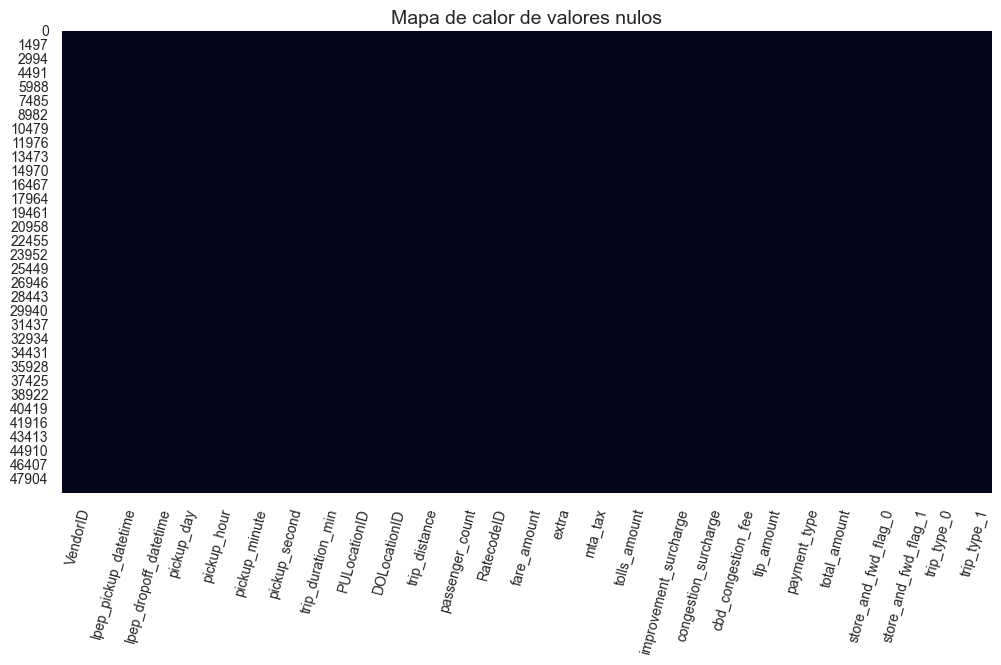

In [21]:
# Mapa de calor de valores nulos
plt.figure(figsize=(12, 6))
sns.heatmap(df_prep_knn.isnull(), cbar=False)
plt.title("Mapa de calor de valores nulos")
ax = plt.gca()
ax.tick_params(axis='x', rotation=75)

# Feature Engineering

In [22]:
df_prep = df_prep_knn.copy()

## Características Temporales

In [23]:
# Create pickup_date column from lpep_pickup_datetime if not already present
if 'pickup_date' not in df_prep.columns:
	df_prep['pickup_date'] = df_prep['lpep_pickup_datetime'].dt.date

# Extraer el día de la semana usando los datos disponibles (only if not already present)
if 'pickup_day_of_week' not in df_prep.columns:
	df_prep['pickup_day_of_week'] = df_prep['lpep_pickup_datetime'].dt.dayofweek

# Extraer día de la semana (método 1 - usando >= 5) (only if not already present)
if 'pickup_week' not in df_prep.columns:
	df_prep['pickup_week'] = df_prep['pickup_day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Es fin de semana si es sábado (5) o domingo (6) (método 
if 'pickup_is_weekend' not in df_prep.columns:
	df_prep['pickup_is_weekend'] = df_prep['pickup_day_of_week'].isin([5, 6]).astype(int)

#Categorizar el día en Manaña, Tarde, Noche
df_prep['pickup_time_of_day'] = pd.cut(
	df_prep['pickup_hour'],
	bins=[0, 5, 12, 17, 21, 24],
	labels=['Night', 'Morning', 'Afternoon', 'Evening', 'Late Night'],
	right=False,
	ordered=False
)
# hora Punta 
df_prep['is_peak_hour'] = df_prep['pickup_hour'].apply(lambda x: 1 if (7 <= x <= 9) or (16 <= x <= 19) else 0)

## Caracteristicas del viaje

In [24]:
#Calcular promedio de velocidad del viaje (millas por hora)
df_prep['average_speed_mph'] = np.where(
    df_prep['trip_duration_min'] > 0,
    (df_prep['trip_distance'] / (df_prep['trip_duration_min'] / 60)).round(2),
    0
)

#Costo por milla: Calcular total_amount / trip_distance o fare_amount / trip_distance. (¡Ojo con divisiones por cero!).
df_prep['cost_per_mile_total'] = np.where(
    df_prep['trip_distance'] > 0,
    (df_prep['total_amount'] / df_prep['trip_distance']).round(2),
    0
)

#Costo por minuto: Calcular total_amount / trip_duration_min o fare_amount / trip_duration_min. (¡Ojo con divisiones por cero!).
df_prep['cost_per_minute_total'] = np.where(
    df_prep['trip_duration_min'] > 0,
    (df_prep['total_amount'] / df_prep['trip_duration_min']).round(2),
    0
)

#Porcentaje de propina: Calcular (tip_amount / fare_amount) * 100 o (tip_amount / total_amount) * 100. (Manejar casos donde fare_amount o total_amount sean cero).
df_prep['tip_percentage_fare'] = np.where(
    df_prep['fare_amount'] > 0,
    (df_prep['tip_amount'] / df_prep['fare_amount'] * 100).round(2),
    0
)

#Ratio de peajes sobre tarifa: tolls_amount / fare_amount.
df_prep['tolls_to_fare_ratio'] = np.where(
    df_prep['fare_amount'] > 0,
    (df_prep['tolls_amount'] / df_prep['fare_amount']).round(2),
    0
)

#Suma de recargos: extra + mta_tax + improvement_surcharge + congestion_surcharge + cbd_congestion_fee.
df_prep['surcharges_total'] = (df_prep['extra'] + df_prep['mta_tax'] + df_prep['improvement_surcharge'] + df_prep['congestion_surcharge'] + df_prep['cbd_congestion_fee']).round(2)

#Ratio de recargos sobre total: Suma de recargos / total_amount.
df_prep['surcharges_to_total_ratio'] = np.where(
    df_prep['total_amount'] > 0,
    (df_prep['surcharges_total'] / df_prep['total_amount']).round(2),
    0
)

# Agrupación por dominio semántico

In [25]:
# Agrupación por dominio semántico
feature_domains = {
    'temporal_features': [
        'pickup_day', 'pickup_day_of_week',
        'pickup_is_weekend', 'pickup_hour', 'pickup_time_of_day', 'is_peak_hour'
    ],
    'metadata': [
        'VendorID', 'RatecodeID', 'PULocationID', 'DOLocationID', 
        'payment_type','store_and_fwd_flag_0',
        'store_and_fwd_flag_1','trip_type_0','trip_type_1'
    ],

    'trip_characteristics': [
        'trip_distance', 'passenger_count', 'trip_duration_min', 'average_speed_mph'
    ],
    'fare_breakdown': [
        'fare_amount', 'extra', 'mta_tax', 'tolls_amount',
        'improvement_surcharge', 'congestion_surcharge', 'cbd_congestion_fee',
        'surcharges_total'
    ],
    'tip_metrics': [
        'tip_amount', 'tip_percentage_fare'
    ],
    'efficiency_ratios': [
        'cost_per_mile_total', 'cost_per_minute_total',
        'tolls_to_fare_ratio', 'surcharges_to_total_ratio'
    ],
    'total_amounts': [
        'total_amount'
    ]
}

# Crear lista ordenada desde los grupos
ordered_columns = []
for domain in feature_domains.values():
    ordered_columns.extend(domain)

df_final = df_prep[ordered_columns]

In [26]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler
import numpy as np # Necesario para np.number

# Asumiendo que 'df_final' es tu DataFrame listo antes del escalado
df_minmax = df_final.copy() # Trabaja sobre una copia

# --- 1. Definir las columnas numéricas a escalar ---
# Combina las listas de feature_domains que contienen variables continuas o discretas
features_to_scale_lists = [
    feature_domains.get('temporal_features', []), # Cuidado: Escala solo las numéricas
    feature_domains.get('trip_characteristics', []),
    feature_domains.get('fare_breakdown', []),
    feature_domains.get('tip_metrics', []),
    feature_domains.get('efficiency_ratios', []),
    feature_domains.get('total_amounts', []) 
]

# Aplanar la lista de listas
features_to_scale = [item for sublist in features_to_scale_lists for item in sublist]

# Filtrar para asegurarse de que solo sean numéricas y existan en el DataFrame
target_variable = 'total_amount' # Variable objetivo a excluir del escalado
cols_numericas_final = []
for col in features_to_scale:
    if col in df_minmax.columns and pd.api.types.is_numeric_dtype(df_minmax[col]):
        # Excluir variables binarias (0/1) o con muy pocos valores únicos y el target
        if df_minmax[col].nunique() > 2 and col != target_variable: 
             cols_numericas_final.append(col)

# --- 2. Aplicar MinMaxScaler ---
print("\nAplicando Escalado MinMaxScaler (Normalización [0, 1])")
print("---") # Separador Markdown

if not cols_numericas_final:
    print("No se encontraron columnas numéricas adecuadas para escalar.")
else:
    # Crear el objeto MinMaxScaler
    scaler_minmax = MinMaxScaler()

    # Ajustar (fit) y transformar (transform) las columnas seleccionadas
    # IMPORTANTE: Si tienes train/test split, usa scaler_minmax.fit(X_train[cols_numericas_final])
    # y luego scaler_minmax.transform(...) en ambos X_train y X_test
    
    # Aplicando al DataFrame completo como ejemplo:
    df_minmax[cols_numericas_final] = scaler_minmax.fit_transform(df_minmax[cols_numericas_final])

    # --- Impresión Formateada de Columnas Escaldas ---
    print(f"Se aplicó MinMaxScaler a {len(cols_numericas_final)} columnas:")
    print("-" * 40)
    for i, col in enumerate(cols_numericas_final):
        print(f"- {col}")
        if (i + 1) % 5 == 0: # Imprime un separador cada 5 columnas
             print("-" * 40)
    if len(cols_numericas_final) % 5 != 0: # Separador final
        print("-" * 40)

    print("\nEscalado completado.")
    print(f"Primeras filas del DataFrame escalado (columnas seleccionadas):")
    # Muestra las primeras filas de las columnas escaladas (ahora entre 0 y 1)
    print(df_minmax[cols_numericas_final].head().round(3)) 

print(f"\nDimensiones finales del DataFrame: {df_minmax.shape}")
print("---") # Separador Markdown


Aplicando Escalado MinMaxScaler (Normalización [0, 1])
---
Se aplicó MinMaxScaler a 19 columnas:
----------------------------------------
- pickup_day
- pickup_day_of_week
- pickup_hour
- trip_distance
- passenger_count
----------------------------------------
- trip_duration_min
- average_speed_mph
- fare_amount
- extra
- mta_tax
----------------------------------------
- tolls_amount
- congestion_surcharge
- surcharges_total
- tip_amount
- tip_percentage_fare
----------------------------------------
- cost_per_mile_total
- cost_per_minute_total
- tolls_to_fare_ratio
- surcharges_to_total_ratio
----------------------------------------

Escalado completado.
Primeras filas del DataFrame escalado (columnas seleccionadas):
   pickup_day  pickup_day_of_week  pickup_hour  trip_distance  \
0         0.0                 1.0          0.0          1.000   
1         0.0                 1.0          0.0          0.112   
2         0.0                 1.0          0.0          0.337   
3        

In [27]:
# import pandas as pd
# from sklearn.preprocessing import StandardScaler
# import numpy as np # Necesario para np.number

# # Asumiendo que 'df_final' es tu DataFrame listo antes del escalado
# # Y que ya has dividido tus datos en X_train, X_test, y_train, y_test
# # Si no lo has hecho, puedes aplicar esto al DataFrame completo, pero recuerda
# # que lo ideal es ajustar ('fit') solo en los datos de entrenamiento.
# # Ejemplo con DataFrame completo (recuerda adaptar para train/test split):
# df_scaled = df_final.copy() # Trabaja sobre una copia

# # --- 1. Seleccionar las Características Numéricas a Escalar ---
# # Combina las listas de feature_domains que contienen variables continuas o discretas
# # que se beneficiarían del escalado. Excluimos IDs, variables ya codificadas (dummies) y el target.
# features_to_scale_lists = [
#     feature_domains.get('temporal_features', []), # Cuidado: Escala solo las numéricas (ej. pickup_hour)
#     feature_domains.get('trip_characteristics', []),
#     feature_domains.get('fare_breakdown', []),
#     feature_domains.get('tip_metrics', []),
#     feature_domains.get('efficiency_ratios', []),
#     # 'total_amounts' generalmente es el target o muy correlacionado, decide si escalarlo
#     feature_domains.get('total_amounts', []) 
# ]

# # Aplanar la lista de listas
# features_to_scale = [item for sublist in features_to_scale_lists for item in sublist]

# # Filtrar para asegurarse de que solo sean numéricas y existan en el DataFrame
# # Excluir variables categóricas o binarias que puedan estar en temporal_features
# # y también el target si está en la lista (generalmente 'total_amount' o 'fare_amount')
# target_variable = 'fare_amount' # ¡Asegúrate que esta sea tu variable objetivo!
# cols_numericas_final = []
# print("\nVerificando columnas para escalar:")
# for col in features_to_scale:
#     if col in df_scaled.columns and pd.api.types.is_numeric_dtype(df_scaled[col]):
#         # Excluir variables binarias (0/1) o con muy pocos valores únicos si no deseas escalarlas
#         if df_scaled[col].nunique() > 2 and col != target_variable: 
#              cols_numericas_final.append(col)
#              # print(f" - Incluyendo: {col}") # Descomenta si quieres ver cada columna
#         # else:
#              # print(f" - Omitiendo: {col} (Binaria/Target)") # Descomenta para ver omitidas
#     # else:
#         # print(f" - Omitiendo: {col} (No numérica/No existe)") # Descomenta para ver omitidas

# # --- 2. Aplicar StandardScaler ---
# print("\n## Aplicando Escalado StandardScaler (Estandarización)")
# print("---") # Separador Markdown

# if not cols_numericas_final:
#     print("No se encontraron columnas numéricas adecuadas para escalar.")
# else:
#     # Crear el objeto StandardScaler
#     scaler = StandardScaler()

#     # Ajustar (fit) y transformar (transform) las columnas seleccionadas
#     # IMPORTANTE: Si tienes train/test split, usa scaler.fit(X_train[cols_numericas_final])
#     # y luego scaler.transform(X_train[cols_numericas_final]) y scaler.transform(X_test[cols_numericas_final])
    
#     # Aplicando al DataFrame completo como ejemplo:
#     df_scaled[cols_numericas_final] = scaler.fit_transform(df_scaled[cols_numericas_final])

#     # --- Impresión Formateada de Columnas Escaldas ---
#     print(f"Se aplicó StandardScaler a {len(cols_numericas_final)} columnas:")
#     print("-" * 40)
#     for i, col in enumerate(cols_numericas_final):
#         print(f"- {col}")
#         if (i + 1) % 5 == 0: # Imprime un separador cada 5 columnas para legibilidad
#              print("-" * 40)
#     if len(cols_numericas_final) % 5 != 0: # Separador final si no es múltiplo de 5
#         print("-" * 40)

#     print("\n✓ Escalado completado.")
#     print(f"✓ Primeras filas del DataFrame escalado (columnas seleccionadas):")
#     # Muestra las primeras filas de las columnas escaladas para verificar
#     print(df_scaled[cols_numericas_final].head().round(3)) 

# print(f"\n✓ Dimensiones finales del DataFrame: {df_scaled.shape}")
# print("---") # Separador Markdown

In [28]:
df_final = df_minmax.copy()

# Correlación entre variables

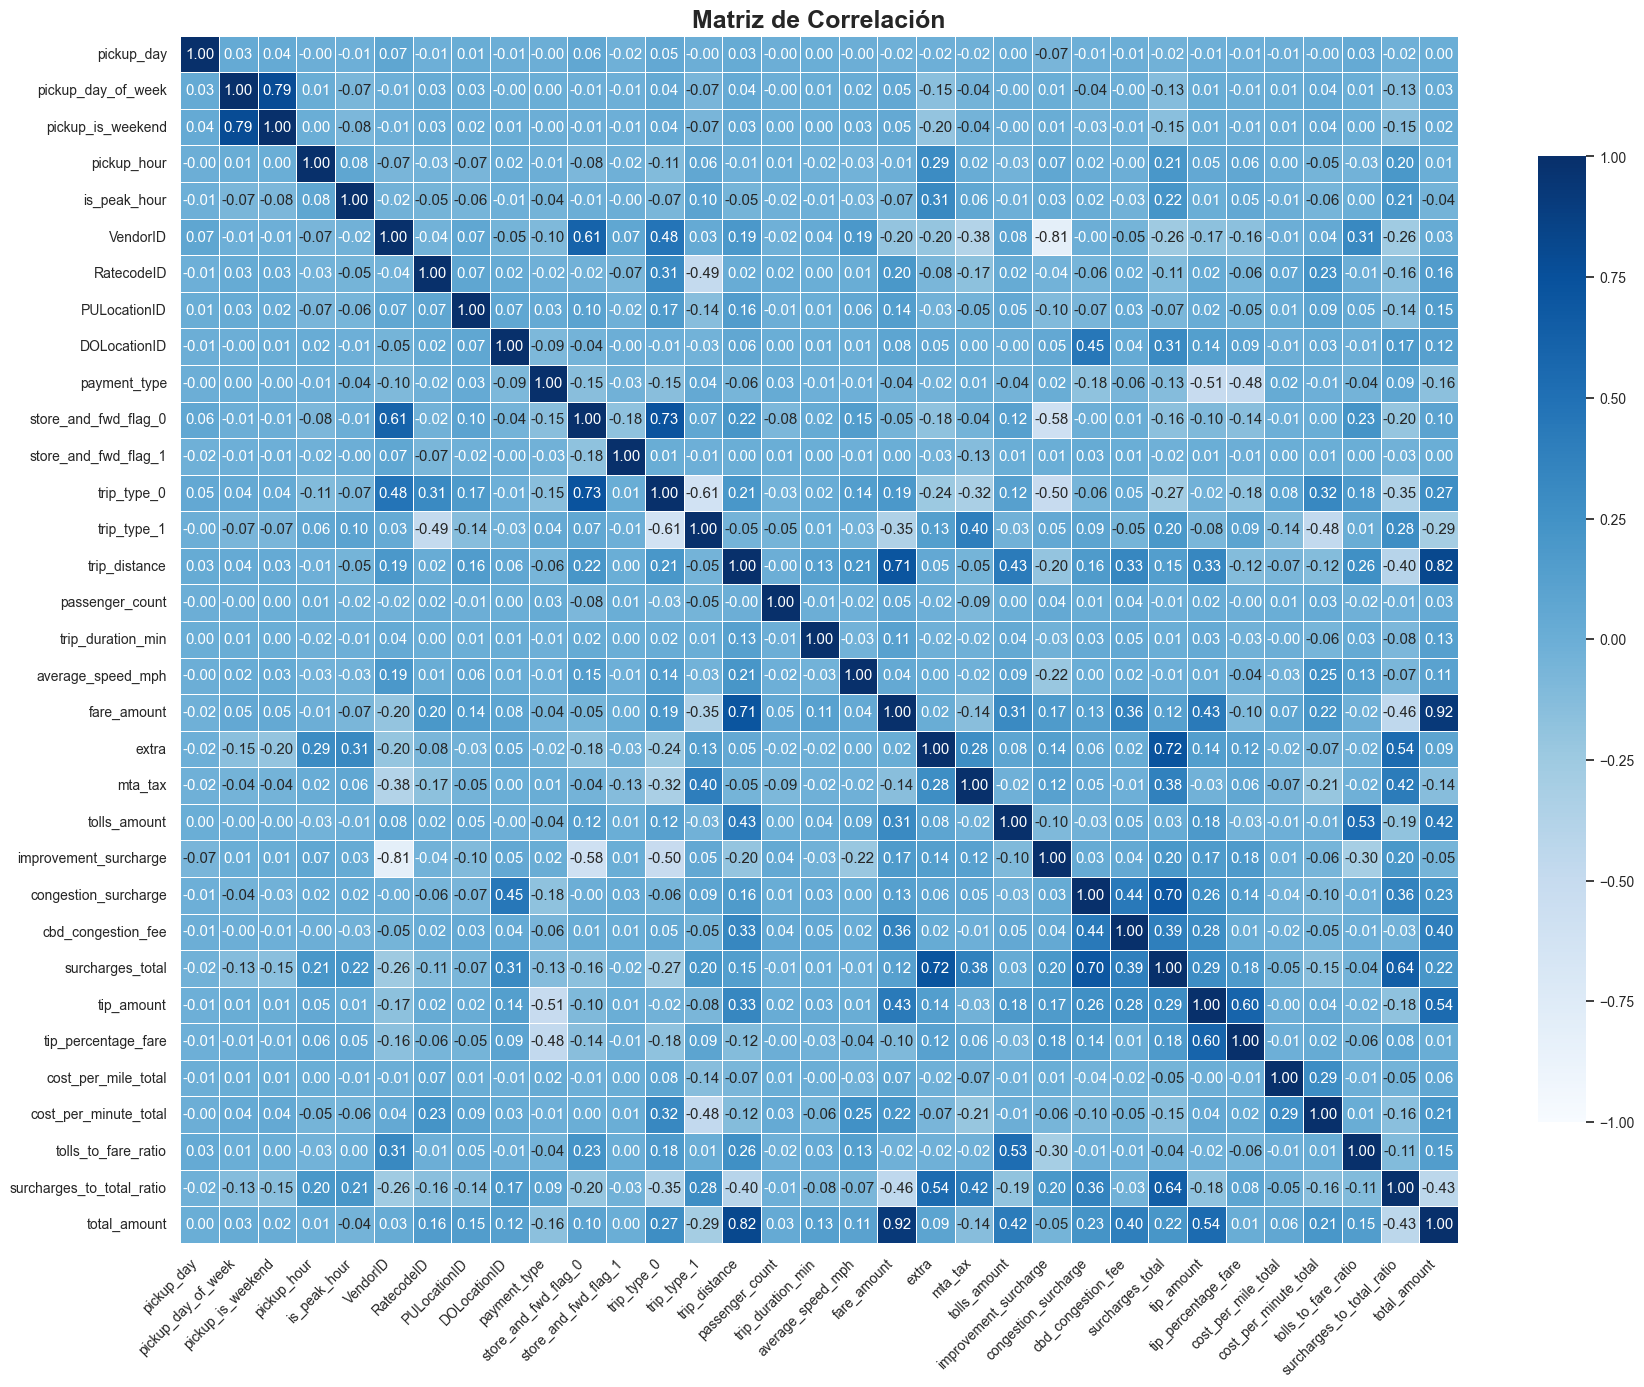

In [29]:
# Seleccionar columnas numéricas y rellenar valores faltantes
numeric_cols_for_corr = df_final.select_dtypes(include=[np.number]).columns
df_prep_for_corr = df_final[numeric_cols_for_corr].copy()
# Calcular la matriz de correlación
corr = df_prep_for_corr.corr()

plt.figure(figsize=(18, 14))
#sns.heatmap(corr, annot=True,cmap='Blues',fmt=".3f",mask=mask,linewidths=.5,cbar_kws={"shrink": .8},vmin=-1,vmax=1)
sns.heatmap(corr, annot=True,cmap='Blues',fmt=".2f",linewidths=.5,cbar_kws={"shrink": .8},vmin=-1,vmax=1)
plt.title("Matriz de Correlación", fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

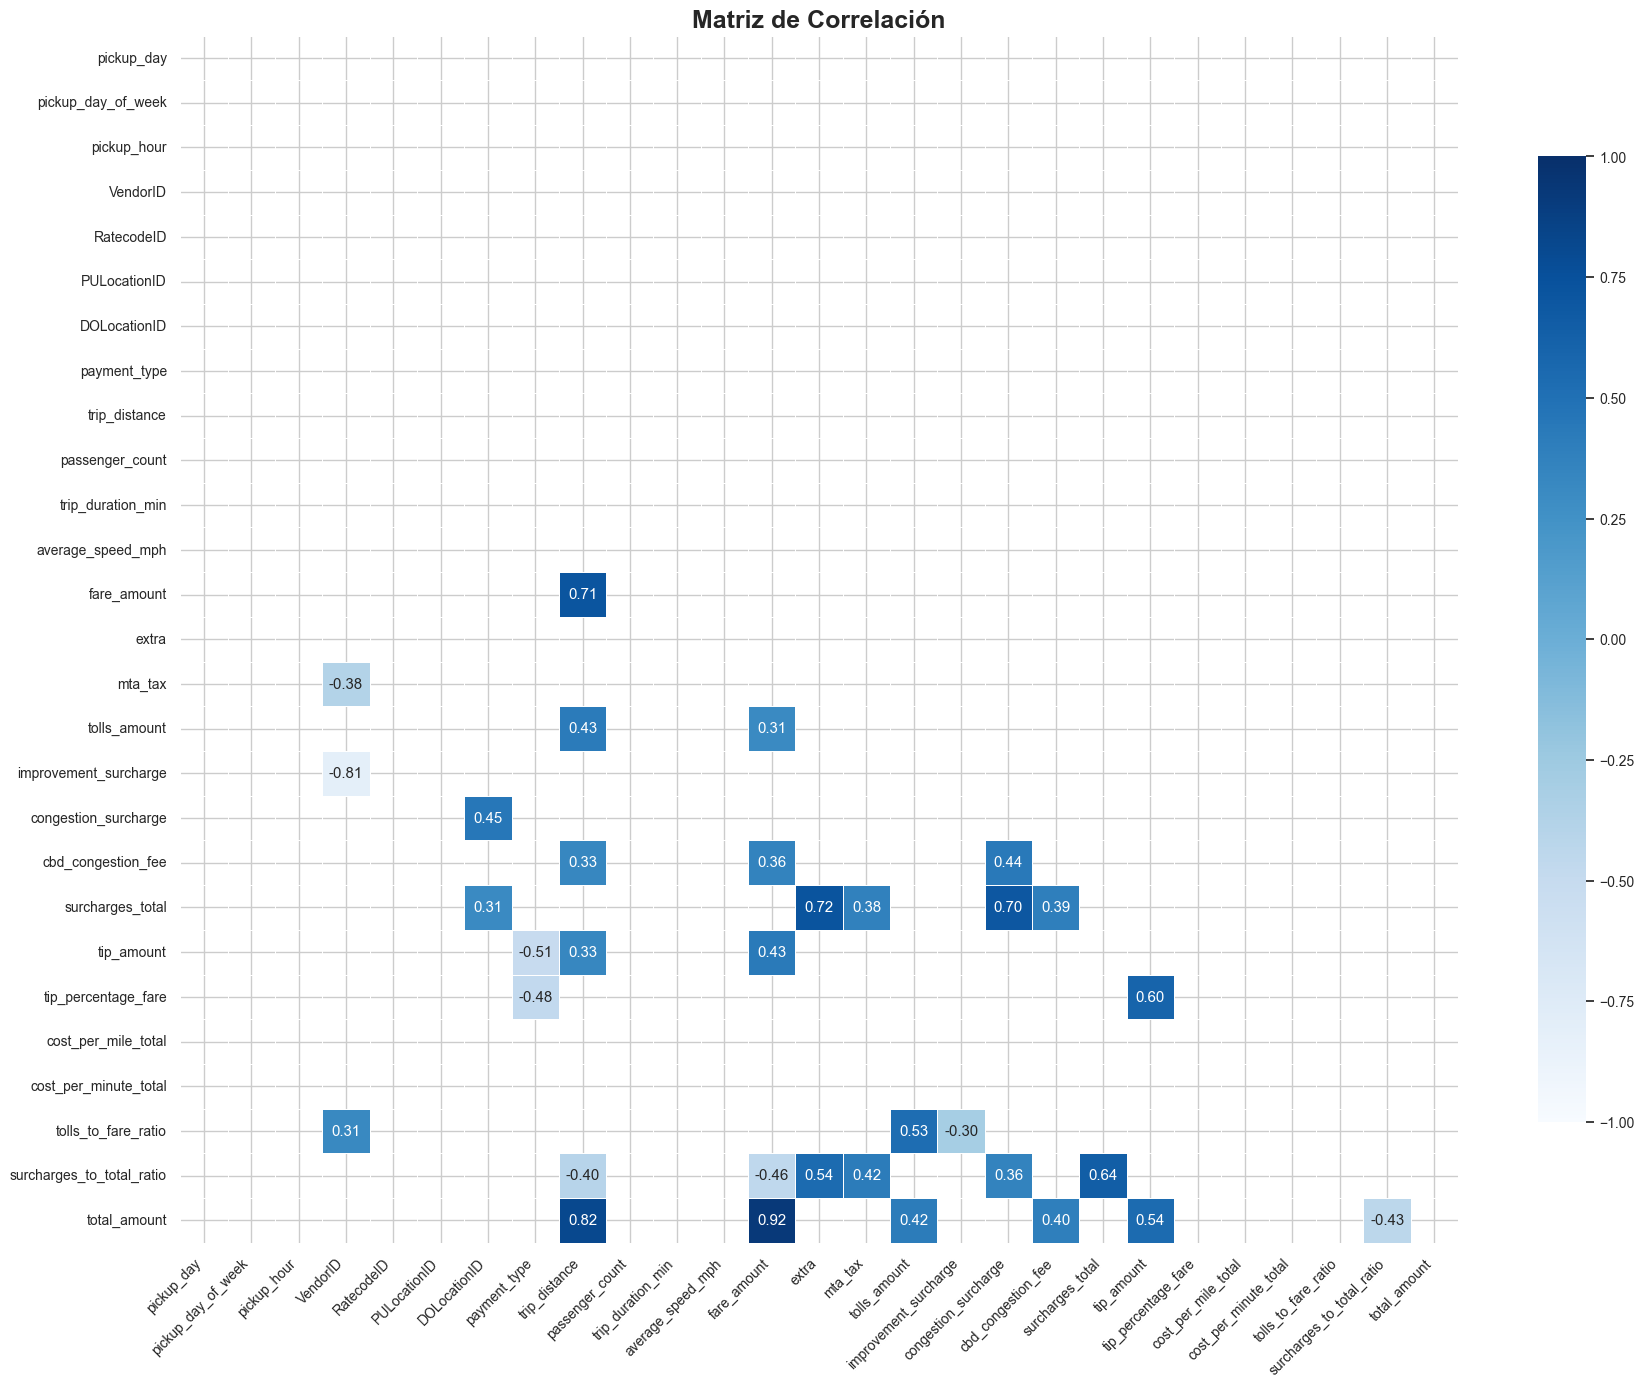

In [30]:
# Seleccionar columnas numéricas y rellenar valores faltantes
numeric_cols_for_corr = df_final.select_dtypes(include=['float64', 'int32', 'Int32']).columns
df_prep_for_corr = df_final[numeric_cols_for_corr].fillna(df_final[numeric_cols_for_corr].median())

# Calcular la matriz de correlación
corr = df_prep_for_corr.corr()

# Que solo se visualice un solo lado de la matriz junto con una mascara para los valores debiles
mask = np.triu(np.ones_like(corr, dtype=bool)) | (np.abs(corr) < 0.3)
plt.figure(figsize=(18, 14))
sns.heatmap(corr, annot=True,cmap='Blues',fmt=".2f",mask=mask,linewidths=.5,cbar_kws={"shrink": .8},vmin=-1,vmax=1)
plt.title("Matriz de Correlación", fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [31]:
df_prep = df_final.copy()

In [32]:
print("\nLimpieza de Columnas: Varianza Cero + Baja Correlación")

df_prep = df_final.copy()
target_col = 'total_amount'

# 1. Varianza cero
zero_var_cols = [col for col in df_prep.select_dtypes(include=['number']).columns 
                if df_prep[col].var() < 1e-10]
if zero_var_cols:
    print(f"✗ Varianza cero: {len(zero_var_cols)} columnas")
    df_prep = df_prep.drop(columns=zero_var_cols)

# 2. Baja correlación (solo columnas numéricas)
if target_col in df_prep.columns:
    # Seleccionar solo columnas numéricas para correlación
    numeric_cols = df_prep.select_dtypes(include=[np.number]).columns
    corrs = df_prep[numeric_cols].corr()[target_col].abs()
    low_corr_cols = corrs[(corrs < 0.2) & (corrs.index != target_col)].index.tolist()
    if low_corr_cols:
        print(f"✗ Baja correlación: {len(low_corr_cols)} columnas")
        df_prep = df_prep.drop(columns=low_corr_cols)

print(f"✓ Final: {df_prep.shape[1]} columnas, {df_prep.shape[0]} filas")


Limpieza de Columnas: Varianza Cero + Baja Correlación
✗ Baja correlación: 21 columnas
✓ Final: 13 columnas, 49390 filas


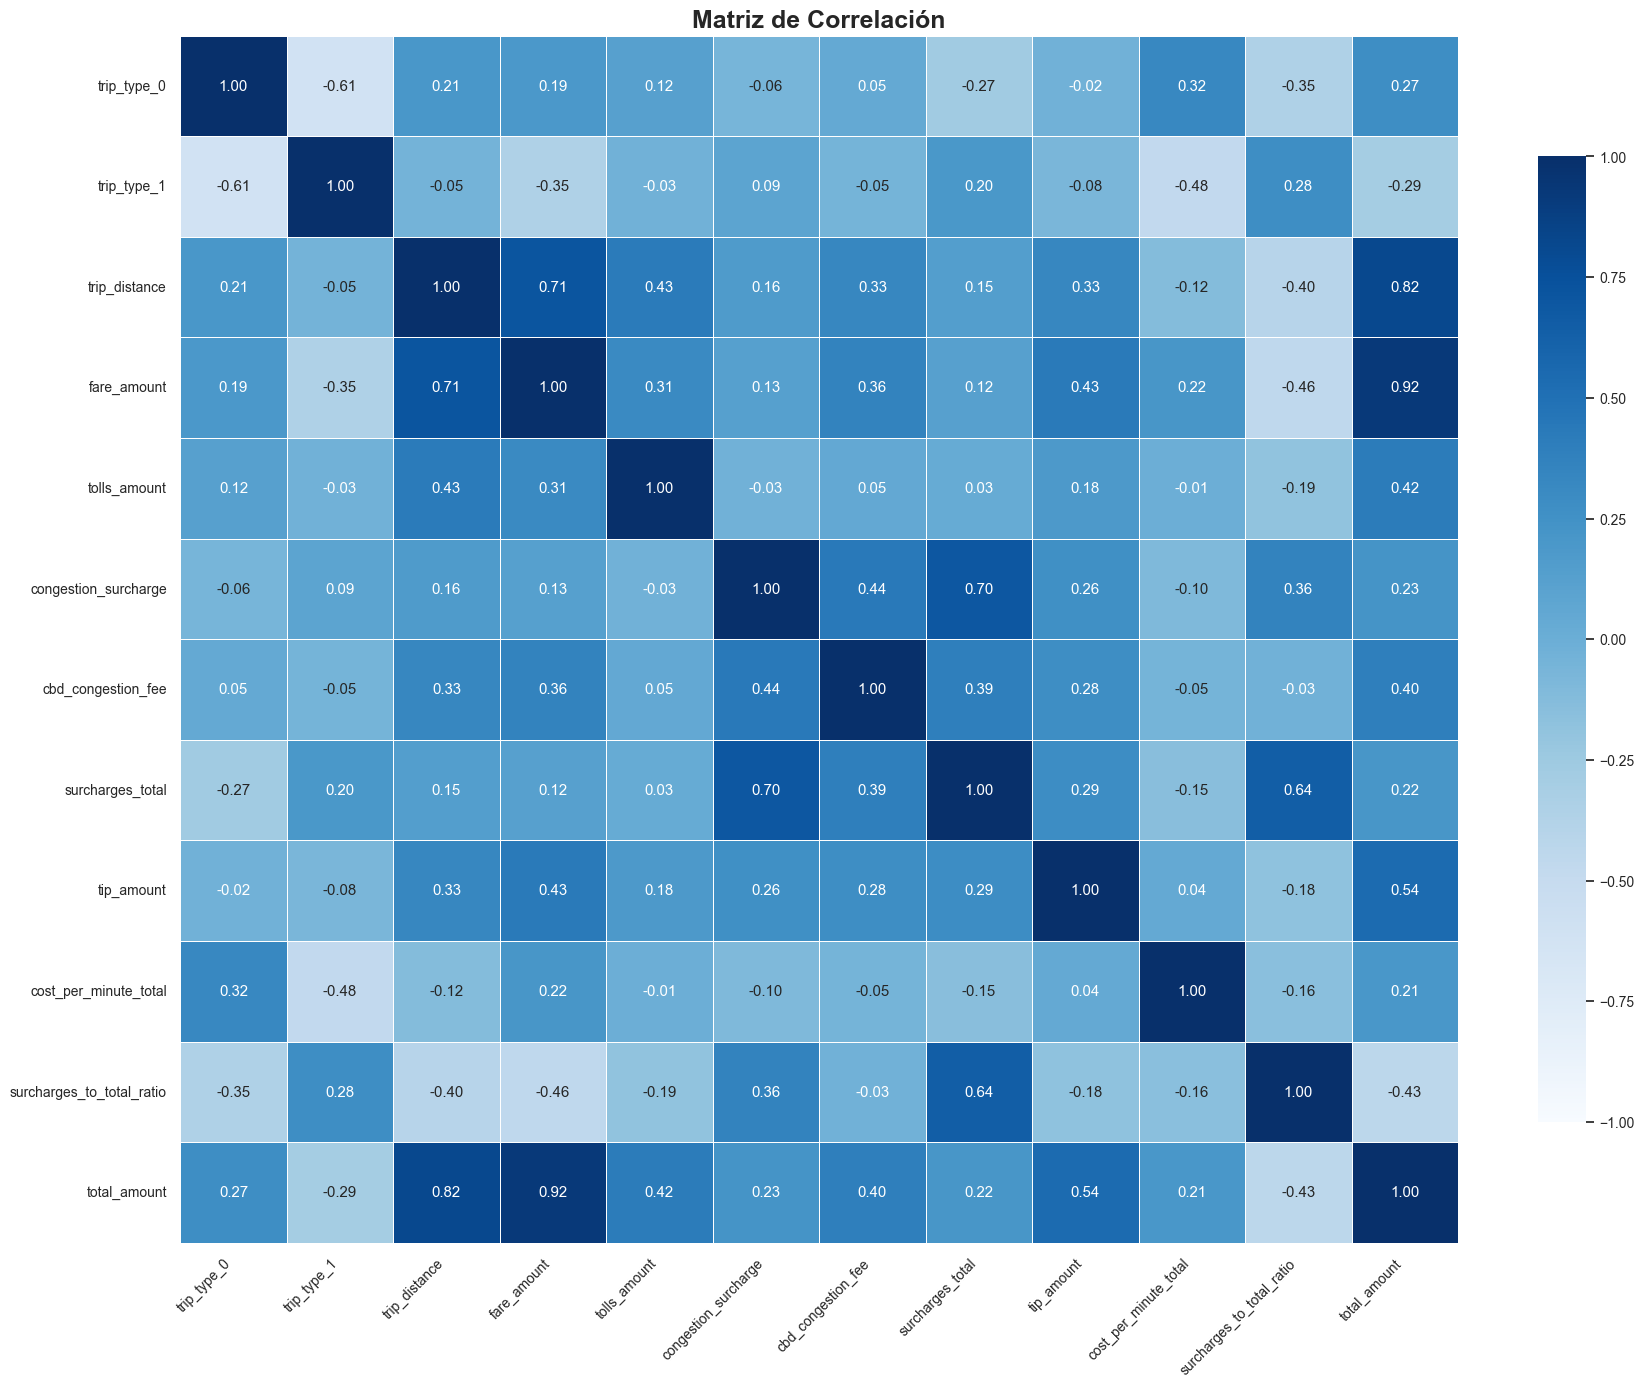

In [33]:
# Seleccionar columnas numéricas y rellenar valores faltantes
numeric_cols_for_corr = df_prep.select_dtypes(include=[np.number]).columns
df_prep_for_corr = df_prep[numeric_cols_for_corr].fillna(df_prep[numeric_cols_for_corr].median())

# Calcular la matriz de correlación
corr = df_prep_for_corr.corr()

plt.figure(figsize=(18, 14))
#sns.heatmap(corr, annot=True,cmap='Blues',fmt=".3f",mask=mask,linewidths=.5,cbar_kws={"shrink": .8},vmin=-1,vmax=1)
sns.heatmap(corr, annot=True,cmap='Blues',fmt=".2f",linewidths=.5,cbar_kws={"shrink": .8},vmin=-1,vmax=1)
plt.title("Matriz de Correlación", fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

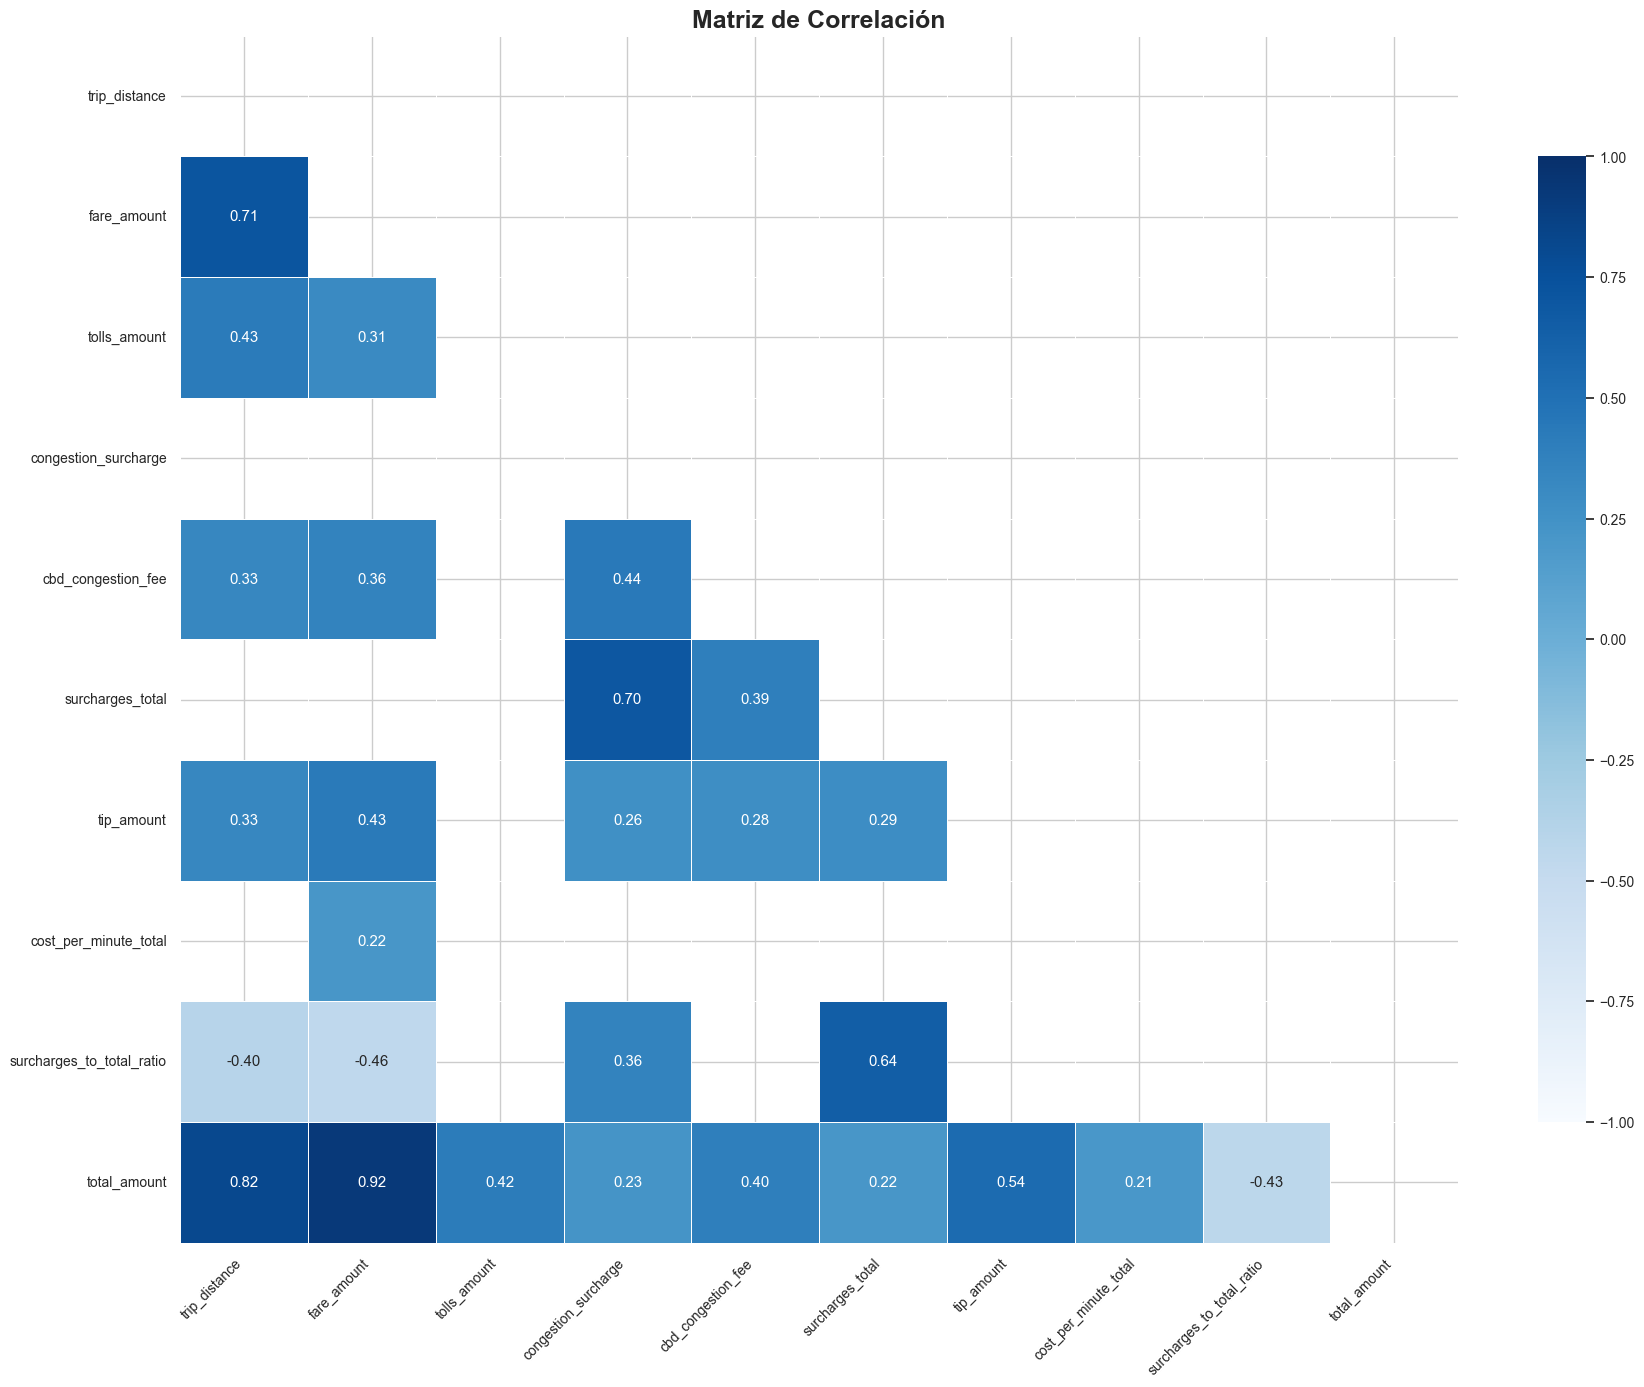

In [34]:
# Seleccionar columnas numéricas y rellenar valores faltantes
numeric_cols_for_corr = df_prep.select_dtypes(include=['float64', 'int32', 'Int32']).columns
df_prep_for_corr = df_prep[numeric_cols_for_corr].fillna(df_prep[numeric_cols_for_corr].median())

# Calcular la matriz de correlación
corr = df_prep_for_corr.corr()

# Que solo se visualice un solo lado de la matriz junto con una mascara para los valores debiles
mask = np.triu(np.ones_like(corr, dtype=bool)) | (np.abs(corr) < 0.2)
plt.figure(figsize=(18, 14))
sns.heatmap(corr, annot=True,cmap='Blues',fmt=".2f",mask=mask,linewidths=.5,cbar_kws={"shrink": .8},vmin=-1,vmax=1)
plt.title("Matriz de Correlación", fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [35]:
# Define el nombre del archivo
dataunderstanding = 'preparation_green_tripdata_2025-06.parquet'

# Guarda el DataFrame df_prep en formato Parquet
try:
    df_prep.to_parquet(dataunderstanding, index=False) 
    print(f"DataFrame guardado exitosamente como '{dataunderstanding}'")
except Exception as e:
    print(f"Error al guardar como Parquet: {e}")
    # Podrías necesitar instalar pyarrow: pip install pyarrow

DataFrame guardado exitosamente como 'preparation_green_tripdata_2025-06.parquet'
